Два класса учатся по различным методикам подготовки к ЕГЭ

В первом классе 30 учеников. Средний балл 74. Стандартное отклонение 8.</br>
Во втором классе 27 учеников. Средний балл 79. Стандартное отклонение 7.

Нулевая гипотеза: вторая методика не даёт статистическое преимущество.</br>
Альтернативная гипотеза: вторая методика даёт статистическое преимущество.</br>
Уровень значимости 5%.

In [1]:
import numpy as np
from scipy import stats as sts
from matplotlib import pyplot as plt

In [2]:
data_1 = np.array([66.32, 79.41, 70.15, 81.27, 68.94, 75.63, 64.88, 80.05, 72.47, 77.19, 69.73, 82.01, 73.56, 67.24, 78.31, 71.09, 65.42, 83.17, 76.84, 63.95, 74.21, 79.87, 68.03, 80.62, 71.78, 75.34, 66.91, 81.45, 73.07, 69.26])
data_2 = np.array([73.48, 84.12, 77.65, 86.33, 75.29, 81.74, 72.11, 85.06, 78.43, 82.91, 76.07, 87.24, 79.58, 74.36, 83.82, 77.15, 71.92, 86.47, 80.29, 73.74, 82.51, 88.03, 76.67, 84.95, 78.13, 81.68, 75.41])

n_1 = 30 #Количество учеников 1 класс
n_2 = 27 #Количество учеников 2 класс

x1_bar = np.mean(data_1) #Средний результат 1 класс
x2_bar = np.mean(data_2) #Средний результат 2 класс

s_1 = 8 #Отклонение от среднего в 1 классе
s_2 = 7 #Отклонение от среднего во 2 классе

a = 0.05 #Уровень значимости
df = n_1 + n_2 - 2 #Степень свободы

mean_diff = x1_bar - x2_bar #Разница средних результатов

sem = np.sqrt(np.var(data_1, ddof=1)/n_1 + np.var(data_2, ddof=1)/n_2)

t_crit = sts.t.ppf(0.975, df)

margin_of_error = t_crit * sem

lower_bound = mean_diff - margin_of_error
upper_bound = mean_diff + margin_of_error

print(f'Средний результат в 1 классе: {x1_bar:.2f}')
print(f'Средний результат во 2 классе: {x2_bar:.2f}')

print(f'Разница средних результатов: {mean_diff}')
print(f'95%-й доверительный интервал: [{lower_bound:.2f},{upper_bound:.2f}]')

Средний результат в 1 классе: 73.61
Средний результат во 2 классе: 79.82
Разница средних результатов: -6.214333333333315
95%-й доверительный интервал: [-9.07,-3.36]


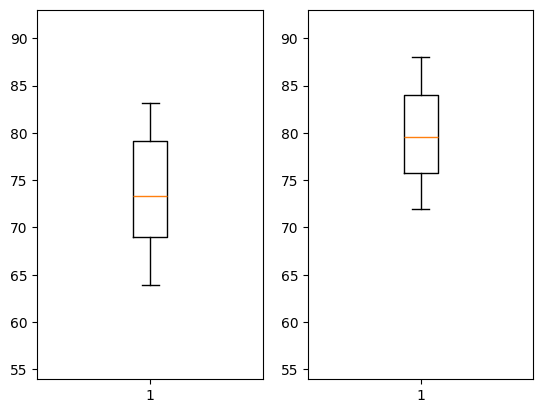

In [3]:
fig, axs = plt.subplots(nrows=1, ncols=2)

axs[0].boxplot(data_1)
axs[0].set_ylim(min(min(data_1)-5, min(data_2))-5, max(max(data_1)+5, max(data_2)+5))

axs[1].boxplot(data_2)
axs[1].set_ylim(min(min(data_1)-5, min(data_2))-5, max(max(data_1)+5, max(data_2)+5))

plt.show()

In [4]:
t_crit = sts.t.ppf(0.975, df)
t_stat, p_value = sts.ttest_ind(data_1, data_2)
print(f't_crit: {t_crit:.2f}')
print(f't_test: {t_stat:.2f}, p_value: {p_value:.8f}')
print(f'Разница средних результатов: {mean_diff:.2f}')
print(f'95%-й доверительный интервал: [{lower_bound:.2f},{upper_bound:.2f}]')

t_crit: 2.00
t_test: -4.32, p_value: 0.00006505
Разница средних результатов: -6.21
95%-й доверительный интервал: [-9.07,-3.36]


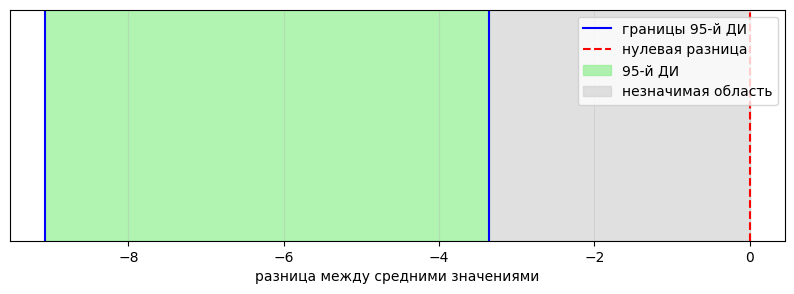

In [5]:
x = np.linspace(lower_bound, upper_bound)
from_x_to_crit = np.linspace(upper_bound, 0)

plt.figure(figsize=(10, 3))
plt.axvline(x=lower_bound, color='b', linestyle='-', label='границы 95-й ДИ')
plt.axvline(x=upper_bound, color='b', linestyle='-')
plt.axvline(x=0, color='r', linestyle='--', label='нулевая разница')

plt.fill_between(x, 0, 1.2, color='lightgreen', alpha=0.7, label='95-й ДИ')
plt.fill_between(from_x_to_crit, 0, 1.2, color='lightgrey', alpha=0.7, label='незначимая область')

plt.ylim(0, 1.2)
plt.grid(True, alpha=0.3)
plt.yticks([])
plt.xlabel('разница между средними значениями')
plt.legend()
plt.show()

При df=(55) наблюдаемая t-статистика=(4.32). Так как t-статистика > 2.0, делаем вывод что разница средних значений статистический значими. Есть основание опровергнуть Н-нулевое.</br>
P-value=0.00007. Вероятность того что разница между значениями случайна — мене 0.007%. P-value < 0.05, сть основание опровергнуть Н-нулевое.</br>
Доверительный интервал -7.85,-2.15. Истинная разница между средними с 95%-й вероятность находится в этом интервале. Не включает 0, разница значима.</br>
T-статистика меньше нуля. Так как мы вычитали результаты первого второго класса из первого, то это означает, что первая группа хуже второй.</br>